<a href="https://colab.research.google.com/github/karangupta2509/ie332-fall2026/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Working with a Prepared Table

**IE 332, Week 5.** Submit the completed notebook to Gradescope by Sunday at
11:59 p.m. This lab is graded for completion.

Start with a table exported from SQL. Use Pandas to select rows and columns,
create useful columns, and prepare numbers for a chart. No SQL queries or
model training are needed in this lab.

Use one prepared table, `brews_orders_export.csv`, from the Brews SQL database.
One row is one order. The six original columns are `order_id`, `store_id`,
`customer_id`, `employee_id`, `order_ts`, and `channel`. Store 2 is PMU.
Some customer IDs are missing. `order_ts` is the order's date and time.
`channel` is `app` for an app order or `counter` for an order placed at the counter.

Upload this single CSV to Colab's Files panel before running the setup.
No database or other CSV is needed. Use Pandas for the six tasks, work in order,
and run each self-check. Use the variable names requested and replace each
`...` with code that calculates the result. The setup, plotting code, and
self-checks are supplied; you do not need to write or explain them.

When asked to display the first few rows, keep the **full requested result**
in the saved variable. Only the display should be shortened. Keep the supplied
setup, plotting code, and self-checks unchanged.


In [5]:
from pathlib import Path
import pandas as pd

DATA_FILE = Path("brews_orders_export.csv")
if not DATA_FILE.exists():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / "Labs_2026/Brews_Exports_Data/brews_orders_export.csv"
        if candidate.exists():
            DATA_FILE = candidate
            break
if not DATA_FILE.exists():
    raise FileNotFoundError("Upload brews_orders_export.csv to Colab's Files panel, then rerun this cell.")

master = pd.read_csv(DATA_FILE, dtype={"customer_id": "Int64"})
print(master.shape)


(51927, 6)


In [6]:
# Supplied self-checks. You do not need to write or explain this code.
_reference = pd.read_csv(DATA_FILE, dtype={"customer_id": "Int64"})

def _msg(ok, name):
    print(("PASS  " if ok else "NOT YET  ") + name)

def _frame(actual, expected):
    pd.testing.assert_frame_equal(actual, expected, check_dtype=False,
                                  check_names=False, rtol=0, atol=1e-10)

def _series(actual, expected):
    pd.testing.assert_series_equal(actual, expected, check_dtype=False,
                                   check_names=False, rtol=0, atol=1e-10)

def check_q1():
    try:
        assert q1_shape == (51927, 6)
        _frame(preview, _reference[["order_id", "order_ts", "channel"]].head(5))
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q1")

def check_q2():
    try:
        expected = _reference.loc[_reference["customer_id"].isna(), ["order_id"]]
        _frame(missing_ids, expected)
        assert q2_count == len(expected)
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q2")

def check_q3():
    try:
        expected = _reference.loc[((_reference["store_id"] == 2) |
                                   (_reference["store_id"] == 3)) &
                                  (_reference["channel"] == "app"),
                                  ["order_id", "store_id", "channel"]]
        _frame(selected_app, expected)
        assert q3_count == len(expected)
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q3")

def check_q4():
    try:
        assert pd.api.types.is_datetime64_any_dtype(master["order_ts"])
        _series(master["order_ts"], pd.to_datetime(_reference["order_ts"]))
        _series(master["hour"], pd.to_datetime(_reference["order_ts"]).dt.hour)
        _series(master["is_pmu"], _reference["store_id"] == 2)
        _series(master["is_app"], _reference["channel"] == "app")
        assert pd.api.types.is_bool_dtype(master["is_pmu"])
        assert pd.api.types.is_bool_dtype(master["is_app"])
        for column in _reference.columns.drop("order_ts"):
            _series(master[column], _reference[column])
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q4")

def check_q5():
    try:
        hours = pd.to_datetime(_reference["order_ts"]).dt.hour
        expected = (_reference["channel"] == "app").groupby(hours).mean()
        _series(shares.sort_index(), expected.sort_index())
        assert q5_app_count == 15593
        assert abs(q5_app_share - 15593 / 51927) < 1e-10
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q5")

def check_q6():
    try:
        expected_X = pd.DataFrame({
            "hour": pd.to_datetime(_reference["order_ts"]).dt.hour,
            "is_pmu": _reference["store_id"] == 2,
        })
        _frame(X, expected_X)
        _series(y, _reference["channel"] == "app")
        assert q6_X_shape == (51927, 2) and q6_y_shape == (51927,)
        assert X.index.equals(y.index)
        ok = True
    except Exception:
        ok = False
    _msg(ok, "Q6")

def check_all():
    for check in [check_q1, check_q2, check_q3, check_q4, check_q5, check_q6]:
        check()

print("Self-checks loaded: check_q1() through check_q6().")


Self-checks loaded: check_q1() through check_q6().


## Q1. Inspect and select columns

Use the supplied `master` table. Store its shape in `q1_shape`.
Create `preview` containing the first five rows of `order_id`, `order_ts`,
and `channel`, in that column order. Display `preview` and `master.dtypes`.
Keep the full `master` table unchanged.


In [8]:
q1_shape = master.shape
preview = master[["order_id", "order_ts", "channel"]].head(5)
print(q1_shape)
display(preview)
display(master.dtypes)


(51927, 6)


,order_id,order_ts,channel
0,1,2025-09-01 09:03:31,counter
1,2,2025-09-01 10:58:37,counter
2,3,2025-09-01 07:08:41,counter
3,4,2025-09-01 16:28:49,counter
4,5,2025-09-01 18:38:47,counter


,0
order_id,int64
store_id,int64
customer_id,Int64
employee_id,int64
order_ts,object
channel,object


In [ ]:
check_q1()


## Q2. Select orders with a missing customer ID

Create a DataFrame `missing_ids` containing only `order_id` for orders whose
`customer_id` is missing. Keep the original row order and row labels. Store the
number of selected orders in `q2_count`. Display the first five selected rows
and the count. A missing ID is not customer 0.


In [9]:
missing_ids = master.loc[master["customer_id"].isna(), ["order_id"]]
q2_count = len(missing_ids)
display(missing_ids.head(5))
print(q2_count)

,order_id
1,2
6,7
13,14
18,19
21,22


18203


In [ ]:
check_q2()


## Q3. Select app orders from two stores

Find all app orders from either PMU (store 2) or store 3. Exclude counter
orders from both stores, and exclude orders from every other store.

Create a DataFrame `selected_app` containing only `order_id`, `store_id`, and
`channel`, in that column order. Keep the original row order and labels.
Store the selected row count in `q3_count`. Display the first five rows
and the count.


In [10]:
selected_app = master.loc[((master["store_id"] == 2) |
                           (master["store_id"] == 3)) &
                          (master["channel"] == "app"),
                          ["order_id", "store_id", "channel"]]
q3_count = len(selected_app)
display(selected_app.head(5))
print(q3_count)


,order_id,store_id,channel
41,42,2,app
43,44,2,app
47,48,2,app
50,51,2,app
52,53,2,app


6495


In [ ]:
check_q3()


## Q4. Create hour and True/False columns

In the full `master` table:

1. Convert `order_ts` to datetime values in `master`. Create `hour` from each timestamp's hour (0 through 23).
2. Create a Boolean column `is_pmu`: True for PMU orders (`store_id == 2`), False otherwise.
3. Create a Boolean column `is_app`: True for app orders (`channel == "app"`), False otherwise.

Display the first five rows of `order_id`, `hour`, `is_pmu`, and `is_app`.
Keep all original rows, their order, and the other original columns unchanged.


In [12]:
master["order_ts"] = pd.to_datetime(master["order_ts"])
master["hour"] = master["order_ts"].dt.hour
master["is_pmu"] = master["store_id"] == 2
master["is_app"] = master["channel"] == "app"
display(master[["order_id", "hour", "is_pmu", "is_app"]].head(5))


,order_id,hour,is_pmu,is_app
0,1,9,False,False
1,2,10,False,False
2,3,7,False,False
3,4,16,False,False
4,5,18,False,False


In [ ]:
check_q4()


## Q5. Compare app use by hour

Compare the proportion of orders placed through the app, using the full
`master` table, not just the selected orders from Q3. Use the hour column
you created in Q4. Combine orders from all dates and all stores: for example,
hour 9 includes every order from 09:00 up to, but not including, 10:00.

- Store the total number of app orders in `q5_app_count`.
- Store the overall app proportion in `q5_app_share`: app orders divided by
  **all orders across all stores**.
- Create a Series `shares` with one value per hour present in the data and
  hours as its row labels (index). Each value is app orders during that hour
  divided by **all orders during that same hour**.

Use proportions from 0 to 1, not percentages from 0 to 100. Keep the unrounded
values in `q5_app_share` and `shares`. Display the count, overall proportion,
and hourly proportions. Round only the displayed proportions to three decimals.
Run the supplied chart cell after your check passes.


In [13]:
q5_app_count = master["is_app"].sum()
q5_app_share = q5_app_count / len(master)
shares = master["is_app"].groupby(master["hour"]).mean()
print(q5_app_count)
print(round(q5_app_share, 3))
display(shares.round(3))


15593
0.3


,is_app
hour,
7,0.311
8,0.303
9,0.294
10,0.300
11,0.308
12,0.293
13,0.301
14,0.300
15,0.289


In [ ]:
check_q5()


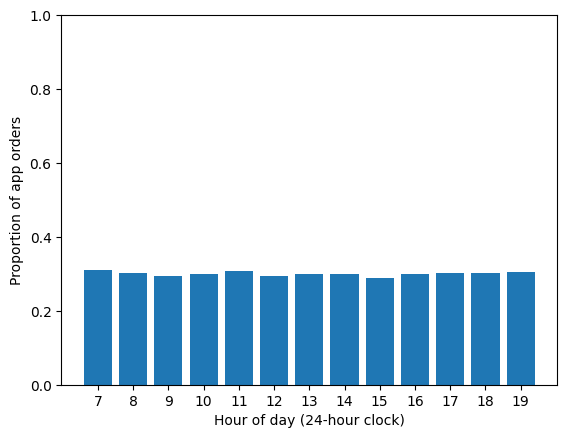

In [14]:
# Supplied chart code. Pandas prepares the numbers; Matplotlib draws them.
import matplotlib.pyplot as plt

if isinstance(shares, pd.Series):
    plt.figure()
    plt.bar(shares.index, shares.values)
    plt.xlabel("Hour of day (24-hour clock)")
    plt.ylabel("Proportion of app orders")
    plt.ylim(0, 1)
    plt.xticks(shares.index)
    plt.show()
else:
    print("Complete Q5 before running the chart.")


## Q6. Select a DataFrame and a Series

Python tools may need a two-dimensional table or a one-dimensional Series.
Practice preparing both from the same rows. Use all rows in `master`, in their
existing order. `X` and `y` are just variable names here; no model is being trained.

- Create a DataFrame `X` with exactly `hour` and `is_pmu`, in that column order.
- Create a Series `y` containing `is_app`.
- Store their shapes in `q6_X_shape` and `q6_y_shape`. Display both shapes and
  the first three rows of `X` and `y`.

Keep the original row labels: each row of `X` and the entry in `y` with the
same label must describe the same order.


In [15]:
X = master[["hour", "is_pmu"]]
y = master["is_app"]
q6_X_shape = X.shape
q6_y_shape = y.shape
print(q6_X_shape)
print(q6_y_shape)
display(X.head(3))
display(y.head(3))


(51927, 2)
(51927,)


,hour,is_pmu
0,9,False
1,10,False
2,7,False


,is_app
0,False
1,False
2,False


In [ ]:
check_q6()


## Before submitting

Restart the runtime and run all cells from top to bottom. Confirm that all
six checks pass, then submit the `.ipynb` file to Gradescope.


In [ ]:
check_all()
